/tmp/ipykernel_273/1645058506.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


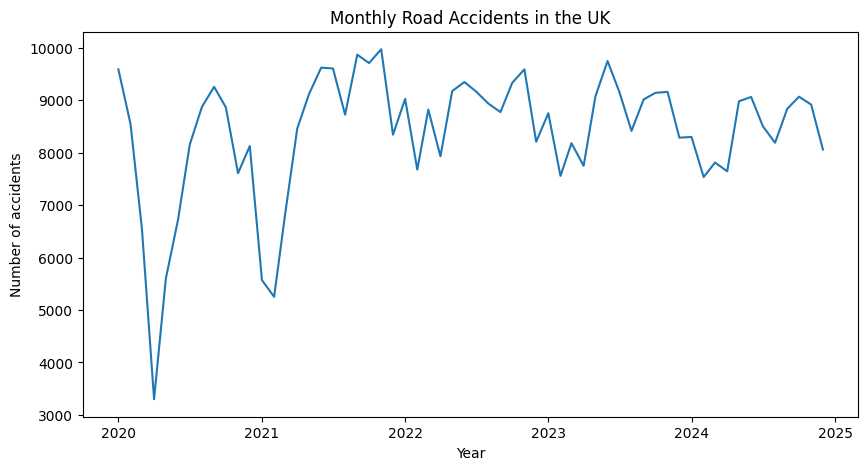

ADF Statistic: -4.788488236475244
p-value: 5.721180469427099e-05


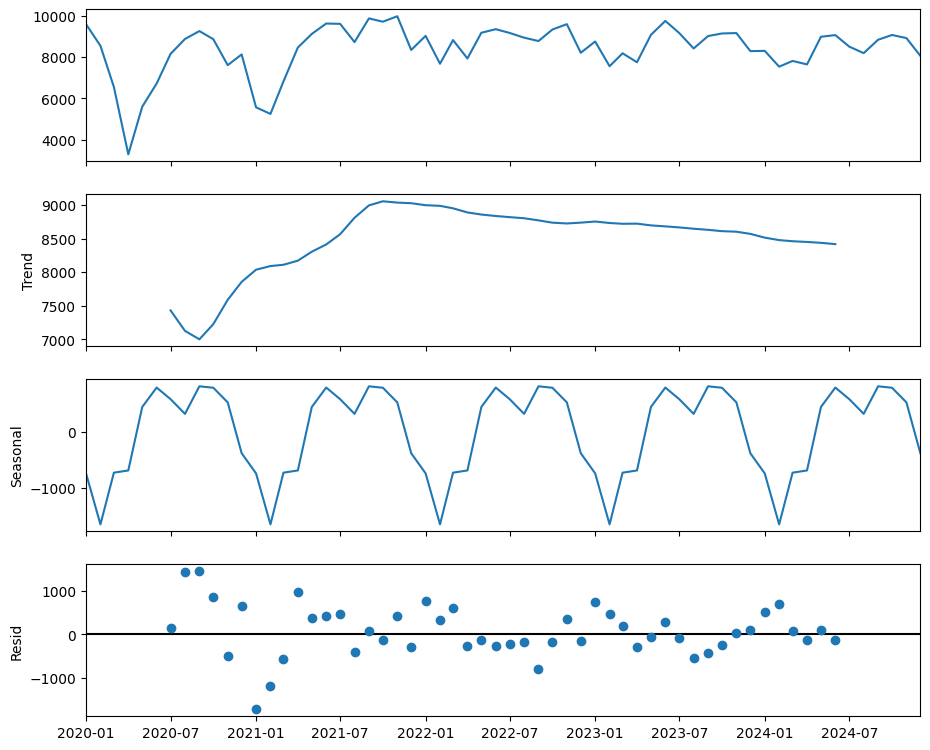

<Figure size 1000x500 with 0 Axes>

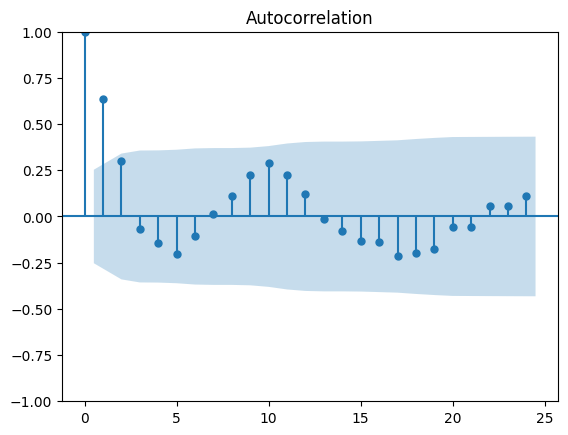

<Figure size 1000x500 with 0 Axes>

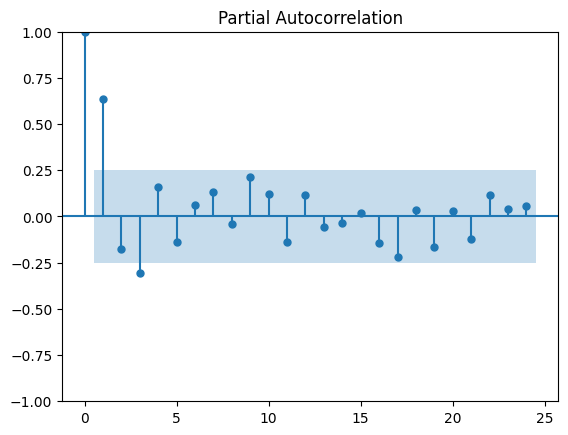

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   60
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -503.336
Date:                            Wed, 11 Mar 2026   AIC                           1012.673
Time:                                    12:13:41   BIC                           1018.956
Sample:                                01-01-2020   HQIC                          1015.130
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9908      0.024     41.138      0.000       0.944       1.038
ar.S.L12       0.1525      0.116   

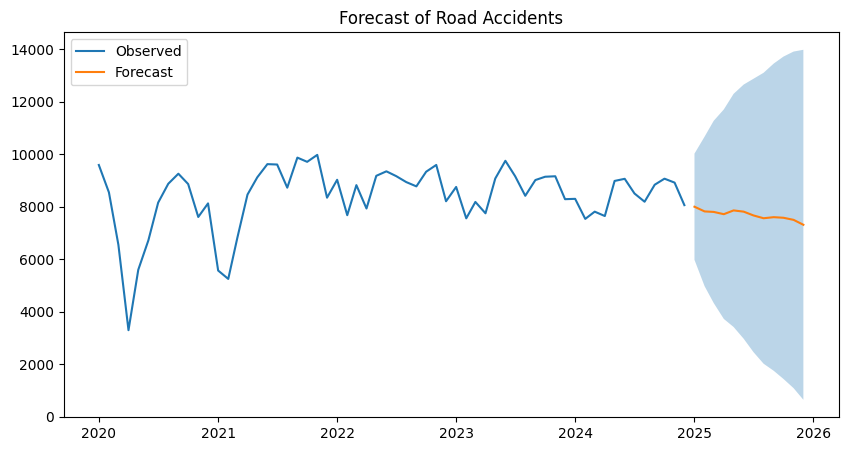

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dft-road-casualty-statistics-collision-last-5-years.csv")
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')
monthly_accidents = df.groupby('month').size()
monthly_accidents.index = monthly_accidents.index.to_timestamp()

plt.figure(figsize=(10,5))
plt.plot(monthly_accidents)
plt.title("Monthly Road Accidents in the UK")
plt.xlabel("Year")
plt.ylabel("Number of accidents")
plt.show()

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_accidents, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(10,8)

from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_accidents)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_acf(monthly_accidents, lags=24)
plt.show()

plt.figure(figsize=(10,5))
plot_pacf(monthly_accidents, lags=24)
plt.show()

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    monthly_accidents,
    order=(1,0,0),
    seasonal_order=(1,0,0,12)
)

results = model.fit()

print(results.summary())

forecast = results.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

plt.figure(figsize=(10,5))

plt.plot(monthly_accidents, label="Observed")

plt.plot(forecast_mean, label="Forecast")

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha=0.3
)

plt.legend()
plt.title("Forecast of Road Accidents")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')